Import thư viện

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [11]:
print("Number of unique customers:", df['customer_unique_id'].nunique())
print("Number of unique orders:", df['order_id'].nunique())
print("Number of unique products:", df['product_id'].nunique())
print("Number of unique product categories:", df['category_en'].nunique())

Number of unique customers: 95414
Number of unique orders: 98660
Number of unique products: 32945
Number of unique product categories: 73


In [ ]:
df = pd.read_csv('./data/online_retail_II_clean.csv')

1.1 Kiểm tra tổng quan dataset

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776580 entries, 0 to 776579
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      776580 non-null  int64  
 1   StockCode    776580 non-null  object 
 2   Description  776580 non-null  object 
 3   Quantity     776580 non-null  int64  
 4   InvoiceDate  776580 non-null  object 
 5   unit_price   776580 non-null  float64
 6   Customer ID  776580 non-null  int64  
 7   Country      776580 non-null  object 
 8   valid_spend  776580 non-null  float64
 9   is_canceled  776580 non-null  bool   
 10  category     776580 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(5)
memory usage: 60.0+ MB


In [9]:
# Xem thống kê các cột số quan trọng
# Lưu ý: Chỉ xem trên đơn thành công để không bị nhiễu bởi dấu âm
stats = df[df['is_canceled'] == False][['Quantity', 'unit_price', 'valid_spend']].describe()
print(stats)

            Quantity     unit_price    valid_spend
count  776580.000000  776580.000000  776580.000000
mean       13.519191       2.935490      21.980067
std       146.096415       4.326401     225.933097
min         1.000000       0.030000       0.060000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000     649.500000  168469.600000


Đại đa số khách hàng (hơn 50%) chỉ mua những đơn hàng nhỏ lẻ tầm £12. Tuy nhiên, các con số trung bình bị kéo vọt lên bởi một nhóm nhỏ khách hàng "tay to"

Giá trị Max của valid_spend (£168,469) gấp hơn 7,600 lần so với mức trung bình. Đây là các đơn hàng bán sỉ. Nếu để nguyên các "cụ cá voi" này khi huấn luyện Model, chúng sẽ làm lệch hoàn toàn khả năng dự báo cho nhóm khách lẻ (chiếm 99% dữ liệu).

75% các dòng hàng khách chỉ mua từ 1 đến 12 sản phẩm. Con số trung vị (Median) là 6, cho thấy đây là hành vi mua sắm cá nhân hoặc hộ gia đình điển hình. Độ lệch chuẩn (Std) lên tới 146, cao gấp 10 lần trung bình. Điều này cho thấy sự xuất hiện của các "siêu đơn hàng" (Max = 80,995).

75% sản phẩm có giá dưới £3.75, và một nửa số mặt hàng (Median) chỉ có giá quanh mức £1.95. Mặc dù đơn giá cao nhất chỉ là £649.50, nhưng đơn hàng lớn nhất lên tới £168,469. Điều này chứng tỏ doanh thu đột biến đến từ số lượng cực lớn

1.2 Kiểm tra missing values

In [11]:
print("="*60)
print("KIỂM TRA MISSING VALUES")
print("="*60)

missing_values = df.isnull().sum()
print(f"\n❌ Missing Values:")
print(missing_values[missing_values > 0])
print(f"\n✅ Không có missing values!" 
      if missing_values.sum() == 0 
      else "⚠️ Có missing values cần xử lý"
    )

KIỂM TRA MISSING VALUES

❌ Missing Values:
Series([], dtype: int64)

✅ Không có missing values!


Kiểm tra dữ liệu trùng lặp

In [ ]:
print(f"Số lượng dòng trùng lặp: {df.duplicated().sum()}")

Số lượng dòng trùng lặp: 0


Kiểm tra Giá trị duy nhất

In [90]:
print(df.nunique())

Invoice        36597
StockCode       4621
Description     5230
Quantity         436
InvoiceDate      604
unit_price       455
Customer ID     5852
Country           41
valid_spend     3554
is_canceled        1
category          12
dtype: int64


2. Trực quan hóa và mối quan hệ giữa các biến

2.1 Phân tích doanh thu theo tháng

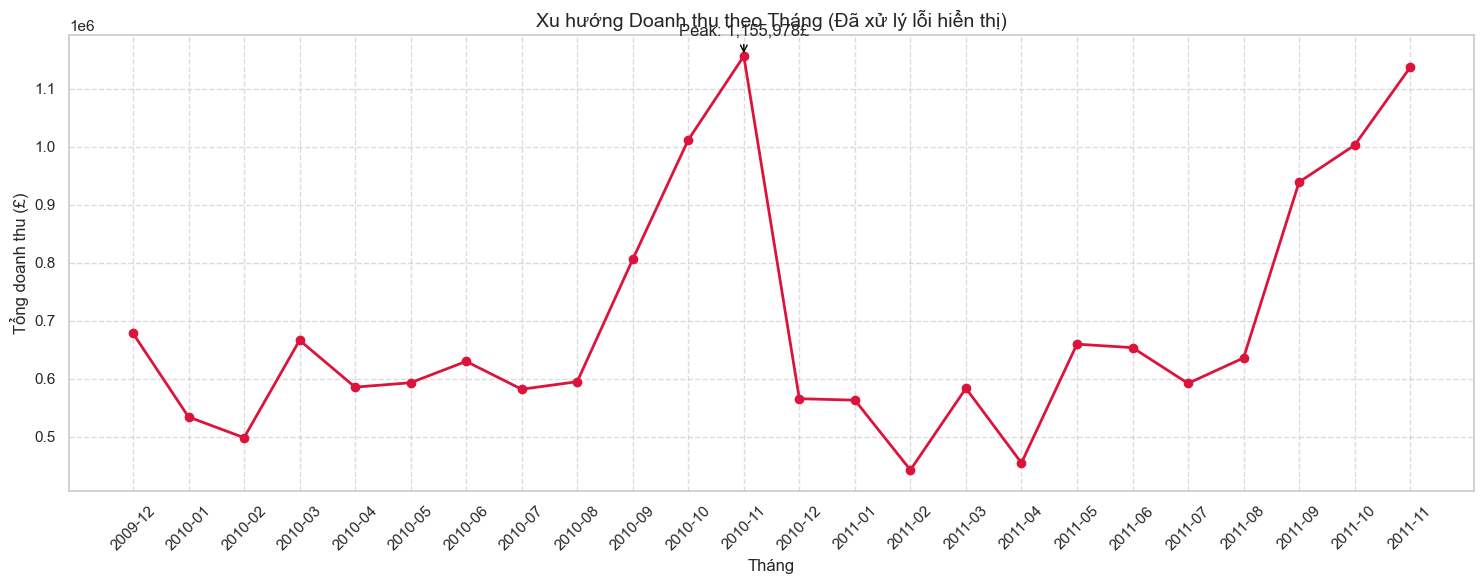

In [22]:
# 1. Chuẩn bị dữ liệu sạch (Bỏ tháng 12/2011)
df_plot = df[(df['is_canceled'] == False) & (df['InvoiceDate'] < '2011-12-01')].copy()
df_plot['Month_Year'] = df_plot['InvoiceDate'].dt.to_period('M').astype(str)

# 2. Groupby để lấy doanh thu theo tháng
monthly_revenue = df_plot.groupby('Month_Year')['valid_spend'].sum()

# 3. Vẽ biểu đồ
plt.figure(figsize=(15, 6))

# Quan trọng: Dùng .reset_index() để đưa Month_Year thành cột thông thường, giúp vẽ dễ hơn
monthly_revenue_df = monthly_revenue.reset_index()

# Vẽ đường biểu diễn
plt.plot(monthly_revenue_df['Month_Year'], monthly_revenue_df['valid_spend'], 
         marker='o', color='crimson', linewidth=2)

# --- PHẦN SỬA LỖI ANNOTATE ---
# Tìm vị trí (index) của tháng có doanh thu cao nhất thay vì dùng tên tháng
max_idx = monthly_revenue_df['valid_spend'].idxmax()
max_val = monthly_revenue_df.loc[max_idx, 'valid_spend']
max_month_name = monthly_revenue_df.loc[max_idx, 'Month_Year']

plt.annotate(f'Peak: {max_val:,.0f}£', 
             xy=(max_idx, max_val), # Dùng index (số thứ tự) thay vì tên tháng
             xytext=(0, 15), 
             textcoords='offset points', 
             ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))
# -----------------------------

plt.title('Xu hướng Doanh thu theo Tháng (Đã xử lý lỗi hiển thị)', fontsize=14)
plt.ylabel('Tổng doanh thu (£)')
plt.xlabel('Tháng')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Doanh thu bùng nổ cực mạnh vào tháng 11 hàng năm (đạt đỉnh trên 1.1 triệu £).

Đây là quy luật lặp lại 100% từ 2010 đến 2011, cho thấy yếu tố mùa lễ hội quyết định 50-60% doanh số của shop.

Các tháng thấp điểm (tháng 1 - tháng 8) giữ mức sàn khoảng 500k - 600k £.

Điều này chứng tỏ shop có một tệp khách hàng trung thành mua sắm đều đặn, không bị phụ thuộc hoàn toàn vào mùa vụ.

2.2 Phân tích phân phối Recency (Số ngày từ lần mua cuối)

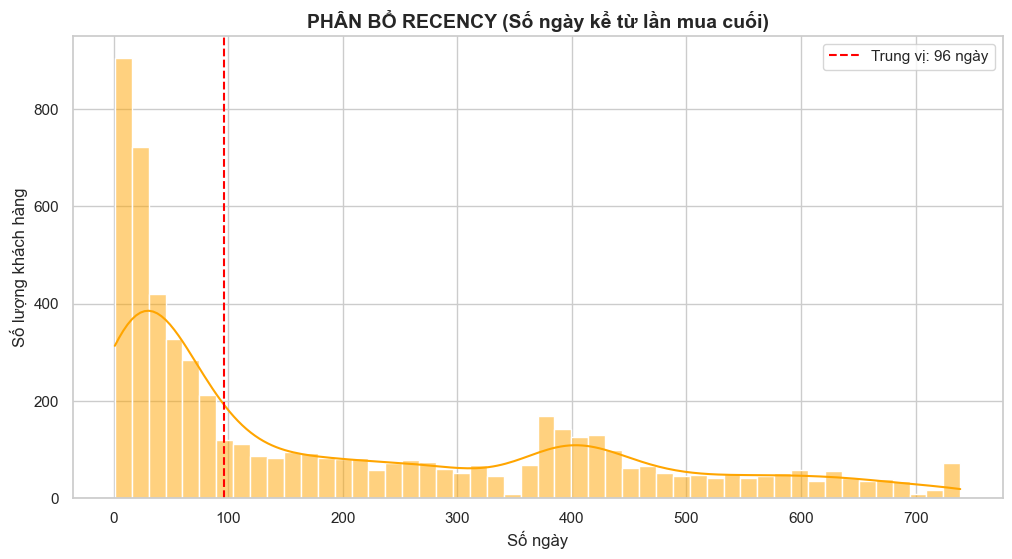

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đảm bảo InvoiceDate là kiểu datetime (Bắt buộc để tính Recency)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Tạo Snapshot Date (Ngày làm mốc: Ngày cuối cùng trong data + 1 ngày)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 3. Tạo bảng customer_rfm (Bước Feature Engineering)
# Chúng ta gom nhóm theo Customer ID và lấy ngày mua hàng gần nhất (max)
customer_rfm = df[df['is_canceled'] == False].groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days
}).reset_index()

customer_rfm.columns = ['Customer ID', 'recency']

# --- BẮT ĐẦU VẼ BIỂU ĐỒ ---
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.histplot(customer_rfm['recency'], bins=50, kde=True, color='orange')

# Thêm đường trung vị để nhận xét EDA sâu hơn
median_val = customer_rfm['recency'].median()
plt.axvline(median_val, color='red', linestyle='--', label=f'Trung vị: {median_val:.0f} ngày')

plt.title('PHÂN BỔ RECENCY (Số ngày kể từ lần mua cuối)', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

Phần lớn khách hàng tập trung ở mốc 0 - 50 ngày. Đây là nhóm khách hàng cốt lõi, mới mua sắm gần đây và có khả năng phản hồi tốt nhất với các chiến dịch marketing.

Đường trung vị (Median) nằm ở mức ~96 ngày. Điều này có nghĩa là 50% khách hàng đã không quay lại trong hơn một quý.

Đồng thời, có một đỉnh phụ xuất hiện quanh mốc 400 ngày. Đây là nhóm khách hàng cũ từ mùa lễ năm trước đã ngừng tương tác.

2.3 Phân tích phân phối tần suất mua hàng

C:\Users\HP\AppData\Local\Temp\ipykernel_11652\2891885835.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_counts.index.astype(int), y=freq_counts.values, palette='viridis')


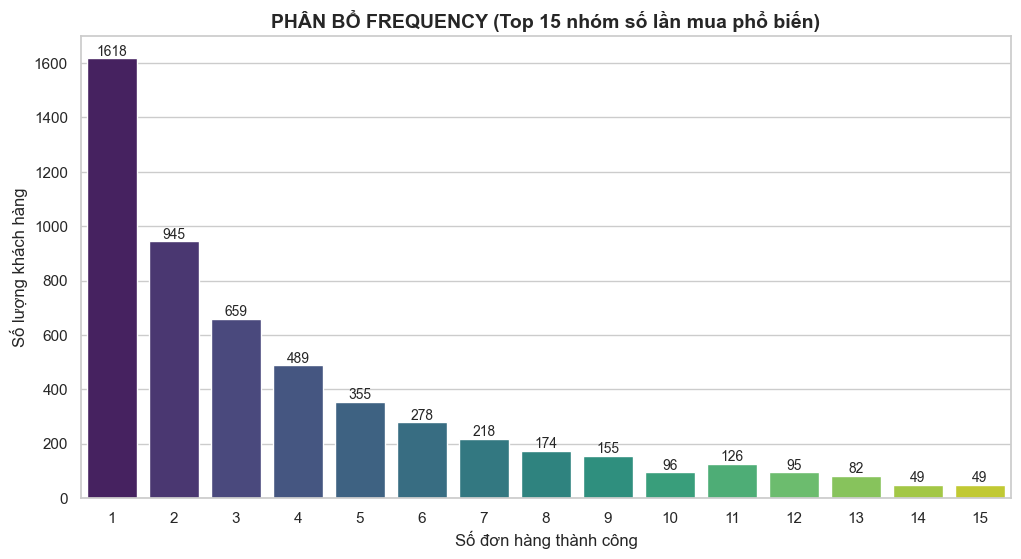

In [55]:
# --- BƯỚC CHUẨN BỊ DỮ LIỆU (Vì bạn chưa có customer_rfm) ---
# Gom nhóm để tính Frequency (Số đơn hàng duy nhất của mỗi khách)
customer_rfm = df[df['is_canceled'] == False].groupby('Customer ID').agg({
    'Invoice': 'nunique'
}).rename(columns={'Invoice': 'frequency'}).reset_index()

plt.figure(figsize=(12, 6))
# Lấy top 15 mốc tần suất để biểu đồ không bị quá dài về bên phải
freq_counts = customer_rfm['frequency'].value_counts().sort_index().head(15)

sns.barplot(x=freq_counts.index.astype(int), y=freq_counts.values, palette='viridis')

plt.title('PHÂN BỔ FREQUENCY (Top 15 nhóm số lần mua phổ biến)', fontsize=14, fontweight='bold')
plt.xlabel('Số đơn hàng thành công')
plt.ylabel('Số lượng khách hàng')

# Thêm số liệu cụ thể trên đầu cột
for i, v in enumerate(freq_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)

plt.show()

Có tới 1,618 khách hàng chỉ mua duy nhất 1 lần. Đây là nhóm lớn nhất, đặt ra thách thức cho model trong việc dự báo liệu họ sẽ trở thành khách quen hay biến mất.

Số lượng khách hàng giảm mạnh từ nhóm mua 1 lần sang mua 2 lần (~42%) và tiếp tục giảm sâu ở các mốc sau. Điều này cho thấy shop đang gặp khó khăn trong việc thuyết phục khách hàng quay lại lần thứ hai.

Từ mốc 5 lần mua trở đi, số lượng khách hàng bắt đầu ổn định hơn (giảm chậm lại). Đây là nhóm khách hàng cốt lõi có thói quen mua sắm định kỳ mà model cần đặc biệt chú ý để nhận diện hành vi.

2.4 Phân tích phân phối tổng chi tiêu

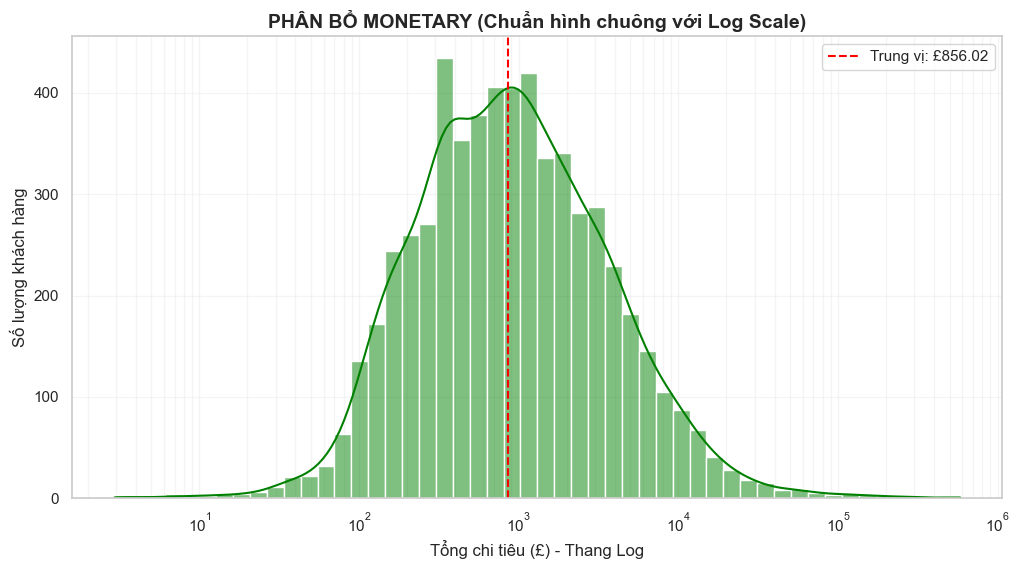

In [56]:
# --- BƯỚC CHUẨN BỊ DỮ LIỆU (Vì bạn chưa có customer_rfm) ---
# Gom nhóm để tính Monetary (Tổng chi tiêu của mỗi khách)
customer_rfm = df[df['is_canceled'] == False].groupby('Customer ID').agg({
    'valid_spend': 'sum'
}).rename(columns={'valid_spend': 'monetary'}).reset_index()

# --- BƯỚC VẼ BIỂU ĐỒ CỦA BẠN ---
plt.figure(figsize=(12, 6))

# 1. Chỉ lấy giá trị dương (Tránh lỗi log(0) hoặc log(số âm))
df_monetary_all = customer_rfm[customer_rfm['monetary'] > 0]

# 2. Dùng log_scale=True để Seaborn tự xử lý thang đo logarit
sns.histplot(data=df_monetary_all, x='monetary', bins=50, kde=True, color='green', log_scale=True)

# Thêm đường trung vị để thấy mốc chi tiêu phổ biến nhất
median_monetary = df_monetary_all['monetary'].median()
plt.axvline(median_monetary, color='red', linestyle='--', label=f'Trung vị: £{median_monetary:.2f}')

plt.title('PHÂN BỔ MONETARY (Chuẩn hình chuông với Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng chi tiêu (£) - Thang Log')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

Sau khi dùng log scale, biểu đồ không còn bị kéo dài mà hiện ra hình chuông cân đối dễ quan sát

Đại đa số khách hàng tập trung chi tiêu trong khoảng từ £300 đến £2,000. Đây là "vùng lõi" tạo ra doanh thu ổn định nhất cho cửa hàng.

Trung vị £856.02 là điểm tập trung chi tiêu điển hình của khách hàng.

Việc dữ liệu chuyển sang hình chuông đẹp cho thấy chi tiêu khách hàng tuân theo quy luật Log-Normal. Đây là tín hiệu tốt để áp dụng các phép biến đổi toán học (như Log Transformation) giúp tăng độ chính xác cho mô hình dự báo sau này.

2.5 Phân tích mối quan hệ giữa Frequency và Monetary

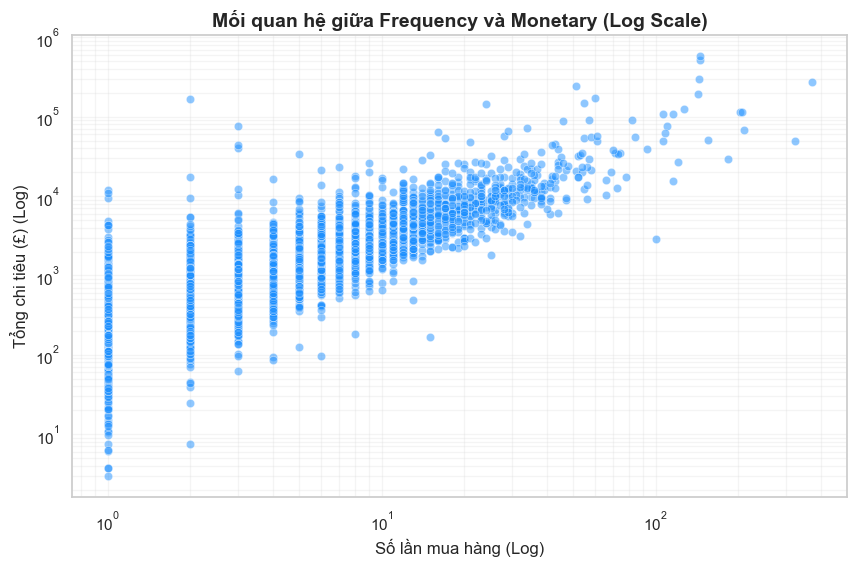

In [58]:
# --- BƯỚC 1: TẠO DỮ LIỆU RFM TỔNG HỢP ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Tính toán các thành phần
rfm_data = df[df['is_canceled'] == False].groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                   # Frequency
    'valid_spend': 'sum'                                    # Monetary
}).reset_index()

rfm_data.columns = ['Customer ID', 'recency', 'frequency', 'monetary']

# --- BƯỚC 2: VẼ BIỂU ĐỒ (Sửa lại x='frequency') ---
plt.figure(figsize=(10, 6))

# Lọc bỏ giá trị <= 0 để tránh lỗi Log scale
plot_df = rfm_data[(rfm_data['frequency'] > 0) & (rfm_data['monetary'] > 0)]

sns.scatterplot(data=plot_df, x='frequency', y='monetary', alpha=0.5, color='dodgerblue')

# Thiết lập thang Log cho cả 2 trục
plt.xscale('log')
plt.yscale('log')

# Cập nhật Title cho đúng với biến (Frequency vs Monetary)
plt.title('Mối quan hệ giữa Frequency và Monetary (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Số lần mua hàng (Log)')
plt.ylabel('Tổng chi tiêu (£) (Log)')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

Khách hàng mua càng nhiều lần (Frequency) thì tổng chi tiêu (Monetary) càng cao. Đây là nền tảng tốt để dự báo giá trị khách hàng.

Nhóm Phổ thông: Tập trung đông nhất ở mức 1-10 lần mua, chi tiêu từ £100 - £1,000.

Nhóm VIP: Một số ít khách hàng mua trên 100 lần với chi tiêu vượt mức £100,000

Dữ liệu bị lệch phải rất nặng (phải dùng Log Scale mới thấy rõ các cụm). Cần xử lý các Outliers (khách hàng chi tiêu cực lớn) để tránh làm nhiễu mô hình dự báo sau này.

In [ ]:
# Tạo df_success bằng cách lọc bỏ các đơn bị hủy
df_success = df[df['is_canceled'] == False].copy()

# Đảm bảo cột ngày tháng đúng định dạng để không bị lỗi khi xử lý sau này
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

2.6 Phân tích doanh thu theo quốc gia

C:\Users\HP\AppData\Local\Temp\ipykernel_11652\625957057.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


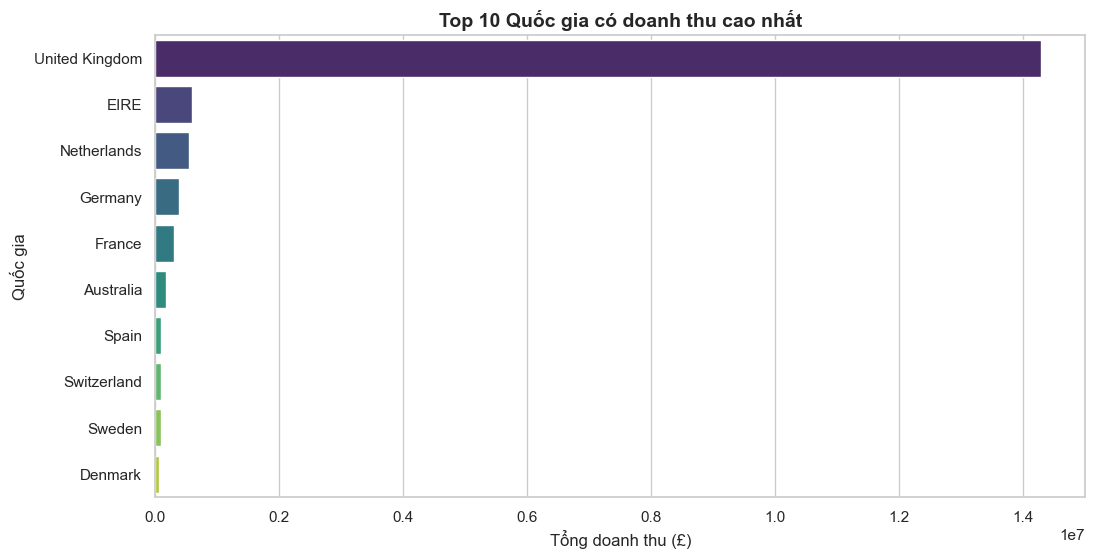

In [ ]:
plt.figure(figsize=(12, 6))
# Tính doanh thu theo quốc gia (Quantity * Price)
df_success['Revenue'] = df_success['valid_spend']
top_countries = df_success.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Quốc gia có doanh thu cao nhất', fontsize=14, fontweight='bold')
plt.xlabel('Tổng doanh thu (£)')
plt.ylabel('Quốc gia')
plt.show()

Vương quốc Anh chiếm tỉ trọng doanh thu vượt trội hoàn toàn so với tất cả các quốc gia còn lại (hơn 14 triệu £). Điều này cho thấy UK là thị trường nội địa và là nguồn thu chính của doanh nghiệp.

Các quốc gia như EIRE (Ireland), Hà Lan (Netherlands), Đức (Germany) và Pháp (France) dẫn đầu nhóm còn lại. Tuy doanh thu thấp hơn nhiều so với UK, nhưng đây là những thị trường quốc tế ổn định nhất.

Khoảng cách quá xa giữa UK và các quốc gia khác báo hiệu rằng khi xây dựng Model Machine Learning, cần xử lý vì hành vi của khách hàng UK có thể sẽ chi phối toàn bộ kết quả dự báo.

2.7 Phân tích đặc điểm phân bổ của các biến số

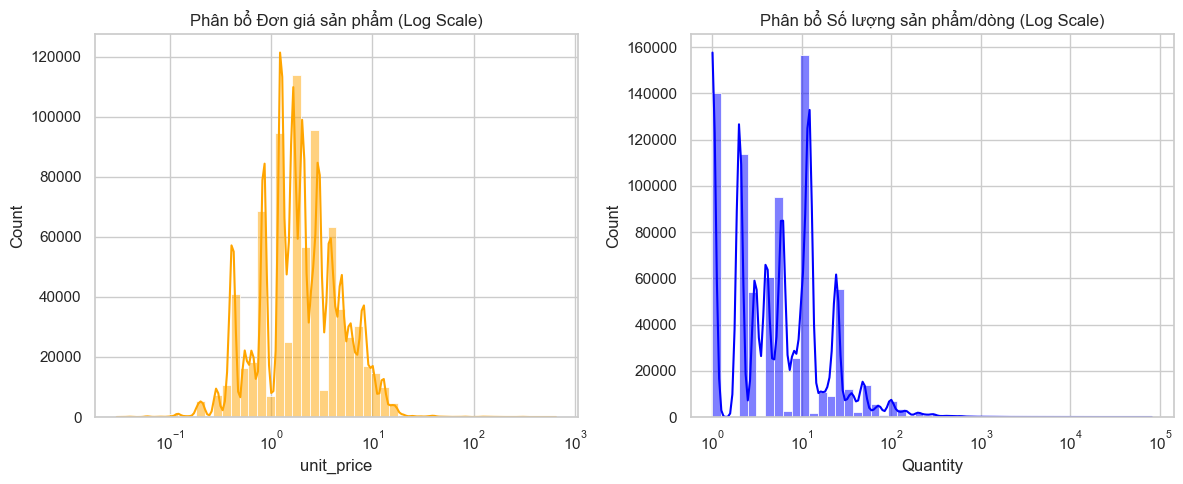

In [39]:
plt.figure(figsize=(12, 5))

# Vẽ phân bổ đơn giá (Price) - dùng log scale vì giá có thể từ rất rẻ đến rất đắt
plt.subplot(1, 2, 1)
sns.histplot(df_success['unit_price'], bins=50, kde=True, color='orange', log_scale=True)
plt.title('Phân bổ Đơn giá sản phẩm (Log Scale)')

# Vẽ phân bổ số lượng trên mỗi dòng hóa đơn (Quantity)
plt.subplot(1, 2, 2)
sns.histplot(df_success['Quantity'], bins=50, kde=True, color='blue', log_scale=True)
plt.title('Phân bổ Số lượng sản phẩm/dòng (Log Scale)')

plt.tight_layout()
plt.show()

Phần lớn sản phẩm tập trung ở mức giá từ £1 đến £5 (mốc $10^0$ đến $10^{0.7}$). Đây là phân khúc hàng giá rẻ/bình dân, cho thấy cửa hàng chủ yếu kinh doanh các mặt hàng tiêu dùng nhanh hoặc phụ kiện nhỏ lẻ.

Phân bổ có dạng "răng cưa" với các đỉnh nhọn ở mốc 1, 10, 12, 24 (các mốc số lượng chẵn theo tá hoặc thùng). Điều này phản ánh hành vi mua hàng có tính toán hoặc mua sỉ theo lô của khách hàng.

Có những đơn hàng lên tới gần 100,000 sản phẩm. Đây là những đơn hàng bán buôn đặc biệt, cần được xử lý riêng để không làm nhiễu mô hình dự báo khách lẻ.

2.8 Phân tích top sản phẩm bán chạy nhất

C:\Users\HP\AppData\Local\Temp\ipykernel_11652\3977721287.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='rocket')


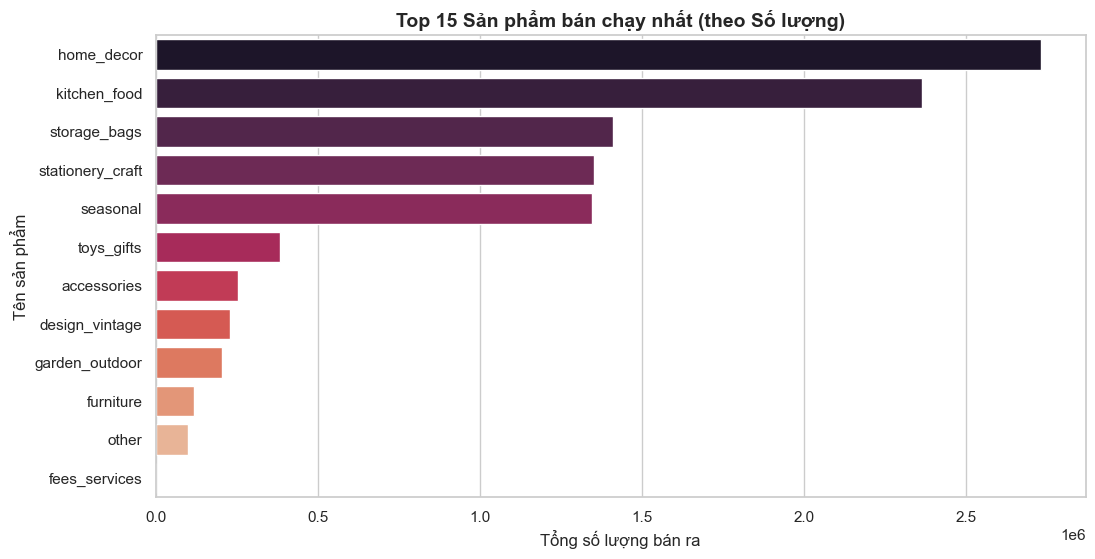

In [86]:
plt.figure(figsize=(12, 6))
top_products = df_success.groupby('category')['Quantity'].sum().sort_values(ascending=False).head(15)

sns.barplot(x=top_products.values, y=top_products.index, palette='rocket')
plt.title('Top 15 Sản phẩm bán chạy nhất (theo Số lượng)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng số lượng bán ra')
plt.ylabel('Tên sản phẩm')
plt.show()

Hai nhóm home_decor và kitchen_food đang đứng đầu bảng với số lượng bán ra vượt trội (trên 2 triệu sản phẩm mỗi loại). Điều này cho thấy khách hàng của shop chủ yếu quan tâm đến việc tân trang nhà cửa và đồ dùng thiết yếu.

Danh mục seasonal có lượng tiêu thụ rất lớn (gần 1 triệu sản phẩm). Điều này gợi ý rằng một phần lớn doanh thu có thể đến từ các dịp lễ hội trong năm (như Giáng sinh hoặc Năm mới), yếu tố này rất quan trọng để đưa vào mô hình dự báo.

2.8 Phân tích mối tương quan giữa Recency, Frequency và Monetary

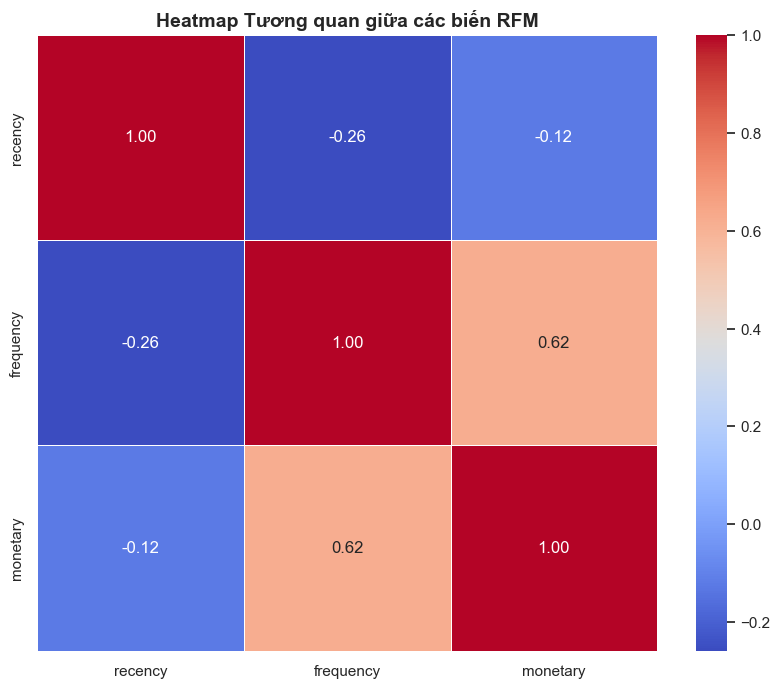

In [42]:
plt.figure(figsize=(10, 8))
# Tính toán tương quan giữa các biến số
corr = customer_rfm[['recency', 'frequency', 'monetary']].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Tương quan giữa các biến RFM', fontsize=14, fontweight='bold')
plt.show()

Frequency và Monetary tương quan thuận khá mạnh (0.62): Đây là cặp biến có mối liên hệ chặt chẽ nhất. Điều này cho thấy khách hàng mua sắm càng thường xuyên thì tổng giá trị chi tiêu của họ càng cao.

Recency tương quan nghịch với cả Frequency (-0.26) và Monetary (-0.12): Mặc dù mức độ tương quan không quá cao, nhưng chiều hướng âm cho thấy xu hướng: khách hàng mới mua gần đây (Recency thấp) thường có tần suất mua và mức chi tiêu cao hơn.

Ngược lại, những khách hàng đã lâu không quay lại (Recency cao) thường có đóng góp giá trị thấp hơn cho doanh nghiệp.

Phân tích cho thấy phần lớn khách hàng có tần suất mua thấp và giá trị chi tiêu nhỏ, trong khi doanh thu bị chi phối bởi một nhóm khách hàng mua sỉ với giá trị giao dịch rất lớn, khiến dữ liệu lệch phải và cần được xử lý outliers trước khi huấn luyện mô hình. Recency và Frequency thể hiện tín hiệu hành vi quan trọng: khách hàng mua gần đây và mua thường xuyên có xu hướng chi tiêu cao hơn và khả năng quay lại tốt hơn. Ngoài ra, tỷ lệ khách hàng chỉ mua một lần khá lớn cùng với yếu tố mùa vụ rõ rệt vào cuối năm cho thấy bài toán dự đoán mua lại mang tính thách thức nhưng phù hợp để áp dụng các đặc trưng hành vi (RFM) nhằm nhận diện sớm nhóm khách hàng có khả năng quay lại trong tháng tiếp theo.